# **Imports, Data Loading, Inspection, and Preprocessing**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
#Load dataset
diabetes=load_diabetes()
X=diabetes.data
y=diabetes.target


In [7]:
pd.DataFrame(X, columns=diabetes.feature_names).head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [9]:
# Combine into a single DataFrame for clean EDA
df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

In [11]:
print("Dataset Head (First 5 Rows) ")
display(df.head())

Dataset Head (First 5 Rows) 


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [13]:
print("\nDataset Summary & Info ")
df.info()


Dataset Summary & Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [14]:
print("\n Dataset Statistical Summary")
display(df.describe())


 Dataset Statistical Summary


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [15]:
# Explicitly check for missing values
missing_count = df.isnull().sum().sum()
print(f"\nTotal missing values in dataset: {missing_count}")
if missing_count > 0:
    df = df.dropna()
    print("Missing values dropped successfully.")


Total missing values in dataset: 0


In [16]:
# Train-test split (BEFORE scaling to prevent data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")


Training set shape: (353, 10)
Testing set shape:  (89, 10)


In [18]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized successfully.")
print("Scaled X_train Sample (First row):")
print(X_train_scaled[0])


Features standardized successfully.
Scaled X_train Sample (First row):
[ 1.49836523  1.06136988  0.21990201  1.13887373  0.72847289  1.05589332
 -0.82445065  0.71103773  0.54748197 -0.06144896]


# **Exploratory Data Analysis Visualizations**

 Generating Feature & Target Distributions 


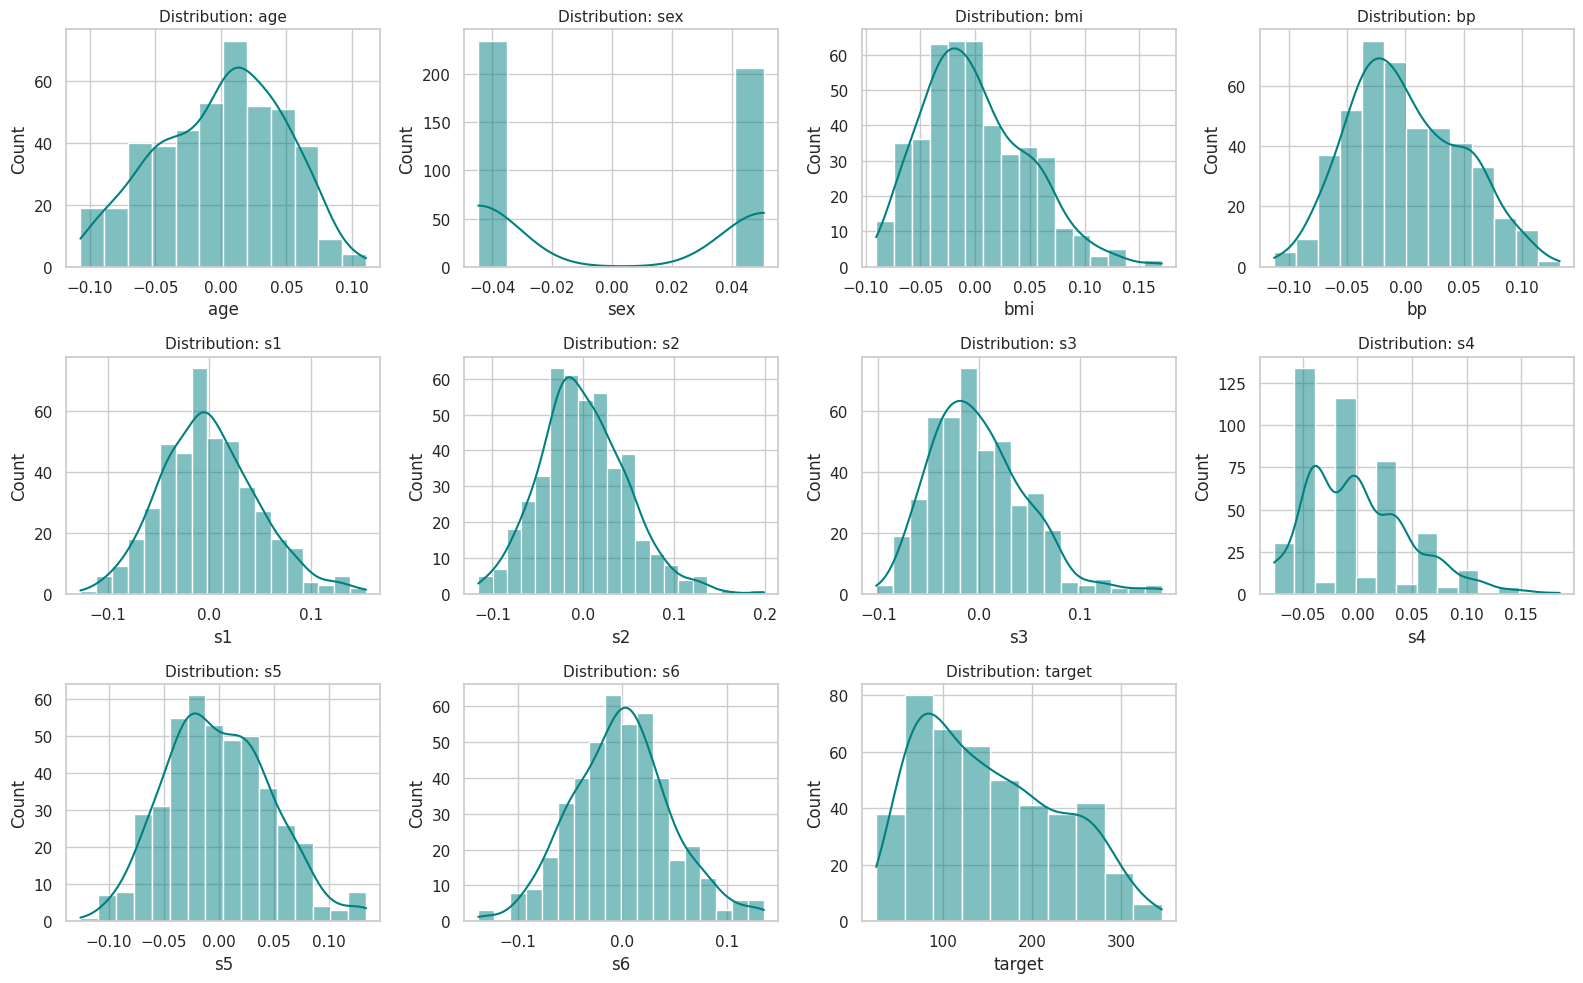

In [21]:
# Set plot style
sns.set_theme(style="whitegrid")

#  Distribution of all features AND the target variable
print(" Generating Feature & Target Distributions ")
plt.figure(figsize=(16, 10))
for i, col in enumerate(df.columns):
    plt.subplot(3, 4, i + 1)
    sns.histplot(df[col], kde=True, color="teal")
    plt.title(f"Distribution: {col}", fontsize=11)
plt.tight_layout()
plt.show()

Generating Correlation Matrix Heatmap 


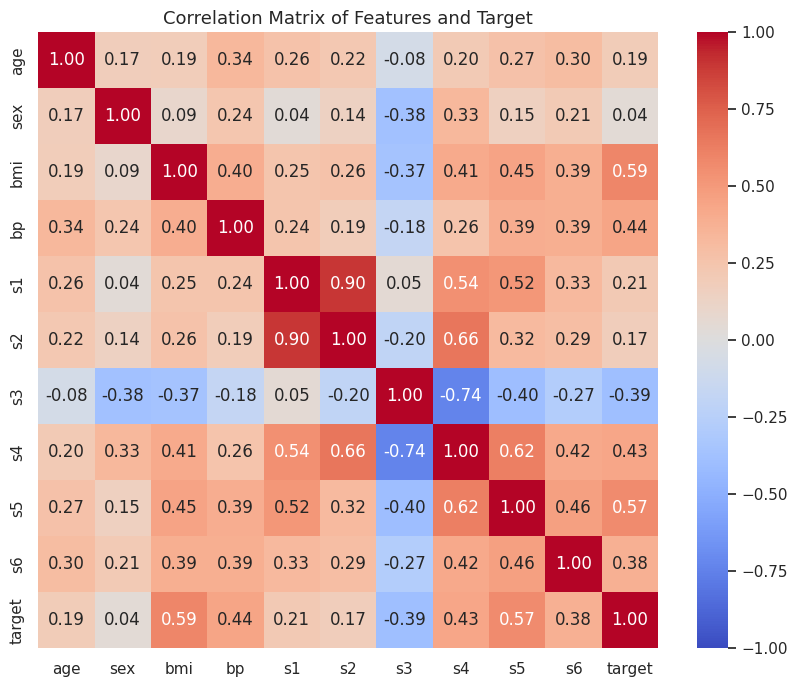

In [20]:
# Correlation Matrix Heatmap (Features & Target)
print("Generating Correlation Matrix Heatmap ")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Features and Target", fontsize=13)
plt.show()

Generating Feature vs. Target Scatter Plots


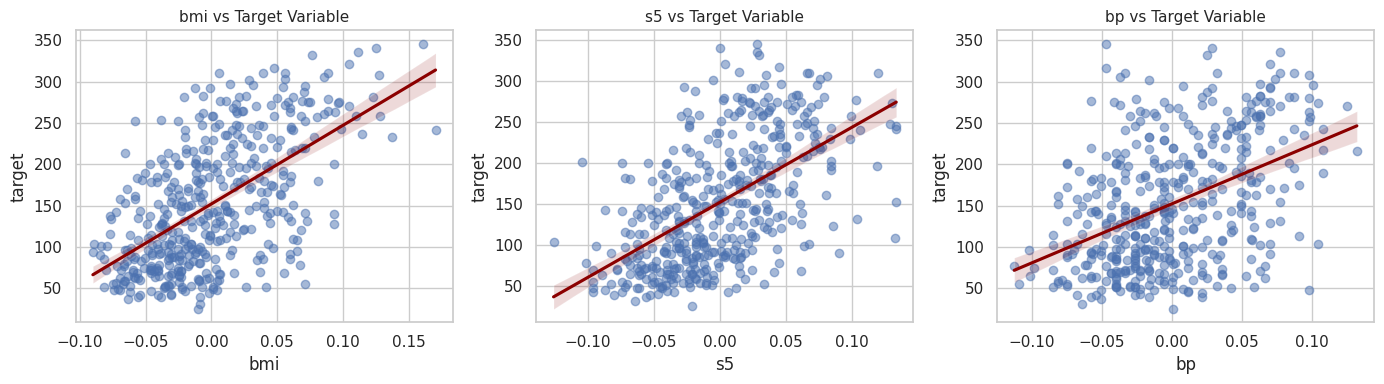

In [22]:
# Scatter Plots with Regression Lines for Top Correlated Features
print("Generating Feature vs. Target Scatter Plots")
plt.figure(figsize=(14, 4))
top_features = ['bmi', 's5', 'bp']
for i, col in enumerate(top_features):
    plt.subplot(1, 3, i + 1)
    sns.regplot(x=col, y='target', data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'darkred'})
    plt.title(f"{col} vs Target Variable", fontsize=11)
plt.tight_layout()
plt.show()

# **Baseline ANN Model(Architecture, Training, & Output Evaluation )**

In [23]:
tf.random.set_seed(42)

# Build Simple Baseline ANN (1 Hidden Layer)
baseline_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(1, activation='linear')
])

print("=== Baseline Model Summary ===")
baseline_model.summary()

=== Baseline Model Summary ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Compile
baseline_model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("\nTraining Baseline Model...")


Training Baseline Model...


In [27]:
#Train the model
history = baseline_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10311.7637 - mae: 78.6911 - val_loss: 6118.7852 - val_mae: 58.5000
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10199.1074 - mae: 78.2841 - val_loss: 6030.0635 - val_mae: 58.1292
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 10050.7139 - mae: 77.7473 - val_loss: 5931.6401 - val_mae: 57.7069
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9893.4307 - mae: 77.1849 - val_loss: 5833.0757 - val_mae: 57.2995
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9737.0674 - mae: 76.6364 - val_loss: 5737.6948 - val_mae: 56.9209
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9585.0195 - mae: 76.1001 - val_loss: 5646.5215 - val_mae: 56.5608
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9438.3027 - mae: 75.5911 - val_loss: 5559.7402 - val_mae: 56.2074
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9297.0674 - mae: 75.1055 - val_loss: 5477.2461 - val_mae: 55.8607
Epoch

In [29]:
# Evaluate on Test Set
y_pred_base = baseline_model.predict(X_test_scaled)
mse_base = mean_squared_error(y_test, y_pred_base)
r2_base = r2_score(y_test, y_pred_base)

print("\n Baseline ANN Model Performance ")
print(f"Mean Squared Error (MSE): {mse_base:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_base):.2f}")
print(f"R2 Score:                 {r2_base:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

 Baseline ANN Model Performance 
Mean Squared Error (MSE): 8291.24
Root Mean Squared Error (RMSE): 91.06
R2 Score:                 -0.5649


In [31]:
# Display sample predictions vs actuals
base_preds_df = pd.DataFrame({
    'Actual Target': y_test[:5],
    'Predicted Target': y_pred_base.flatten()[:5],
    'Difference': y_test[:5] - y_pred_base.flatten()[:5]
})
print("\nSample Baseline Predictions (First 5 test rows):")
display(base_preds_df)


Sample Baseline Predictions (First 5 test rows):


,Actual Target,Predicted Target,Difference
0,219.0,183.620789,35.379211
1,70.0,278.757172,-208.757172
2,202.0,180.302353,21.697647
3,230.0,595.559692,-365.559692
4,111.0,114.797546,-3.797546


# **Improved ANN Model (Building, Training & Output Evaluation)**

In [32]:
tf.random.set_seed(42)

# Build Deep Regularized ANN
improved_model = Sequential([
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

print("=== Improved Model Summary ===")
improved_model.summary()

=== Improved Model Summary ===


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Custom Optimizer
opt = tf.keras.optimizers.Adam(learning_rate=0.005)

improved_model.compile(
    optimizer=opt,
    loss='mean_squared_error',
    metrics=['mae']
)
# Early Stopping Callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("\nTraining Improved Model with Early Stopping...")


Training Improved Model with Early Stopping...


In [36]:
# Train
history_imp = improved_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2,callbacks=[early_stop],verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 8537.3496 - mae: 73.4494 - val_loss: 4270.5605 - val_mae: 53.1423
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6470.8101 - mae: 68.8289 - val_loss: 6319.3296 - val_mae: 68.6520
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6597.3325 - mae: 69.3998 - val_loss: 4437.5791 - val_mae: 55.4530
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5683.4507 - mae: 62.9792 - val_loss: 4391.3687 - val_mae: 55.1787
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 5896.0298 - mae: 64.8960 - val_loss: 4928.8418 - val_mae: 60.1098
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 5959.7939 - mae: 66.5089 - val_loss: 4572.2261 - val_mae: 57.2074
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5885.6587 - mae: 65.3655 - val_loss: 4347.5688 - val_mae: 55.2309
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 5894.5400 - mae: 64.5833 - val_loss: 4455.0054 - val_mae: 56.4816
Epoch 9/

In [37]:
print(f"Improved Model Training Stopped at Epoch: {len(history_imp.history['loss'])}")

Improved Model Training Stopped at Epoch: 15


In [39]:
# Evaluate on Test Set
y_pred_imp = improved_model.predict(X_test_scaled)
mse_imp = mean_squared_error(y_test, y_pred_imp)
r2_imp = r2_score(y_test, y_pred_imp)

print("\n Improved ANN Model Performance ")
print(f"Mean Squared Error (MSE): {mse_imp:.2f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse_imp):.2f}")
print(f"R2 Score:                 {r2_imp:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

 Improved ANN Model Performance 
Mean Squared Error (MSE): 4515.08
Root Mean Squared Error (RMSE): 67.19
R2 Score:                 0.1478


In [41]:
# Display sample predictions vs actuals
imp_preds_df = pd.DataFrame({
    'Actual Target': y_test[:5],
    'Predicted Target': y_pred_imp.flatten()[:5],
    'Difference': y_test[:5] - y_pred_imp.flatten()[:5]
})
print("\nSample Improved Predictions (First 5 test rows):")
display(imp_preds_df)


Sample Improved Predictions (First 5 test rows):


,Actual Target,Predicted Target,Difference
0,219.0,225.795593,-6.795593
1,70.0,227.171265,-157.171265
2,202.0,198.287064,3.712936
3,230.0,397.512573,-167.512573
4,111.0,129.551514,-18.551514


# **Performance Comparison Table & Training Curves Visualization**

In [42]:
# Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Baseline ANN', 'Improved ANN'],
    'Test MSE': [mse_base, mse_imp],
    'Test RMSE': [np.sqrt(mse_base), np.sqrt(mse_imp)],
    'Test R2 Score': [r2_base, r2_imp]
})

print("=== Final Performance Comparison Table ===")
display(comparison_df)

=== Final Performance Comparison Table ===


,Model,Test MSE,Test RMSE,Test R2 Score
0,Baseline ANN,8291.244097,91.056269,-0.564931
1,Improved ANN,4515.082699,67.194365,0.147800



 Loss Curves Comparison Plots 


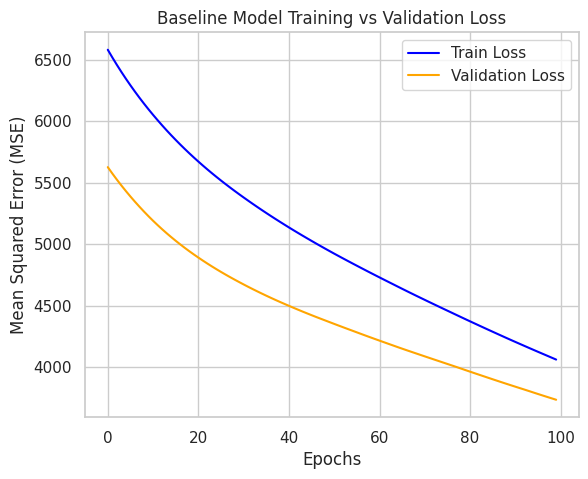

In [43]:
# Plot Loss Curves Side-by-Side
print("\n Loss Curves Comparison Plots ")
plt.figure(figsize=(14, 5))

# Baseline Loss Plot
plt.subplot(1, 2, 1)
plt.plot(history_base.history['loss'], label='Train Loss', color='blue')
plt.plot(history_base.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Baseline Model Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

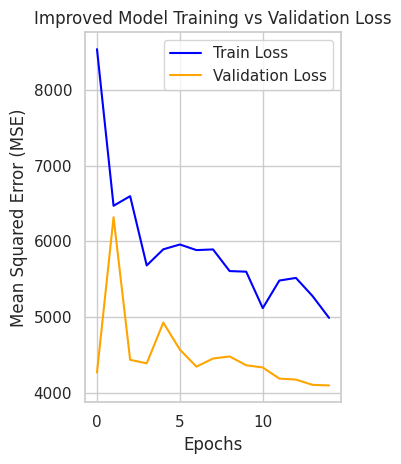

In [44]:
# Improved Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_imp.history['loss'], label='Train Loss', color='blue')
plt.plot(history_imp.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Improved Model Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()

plt.tight_layout()
plt.show()


 Actual vs Predicted Values Scatter Plots 


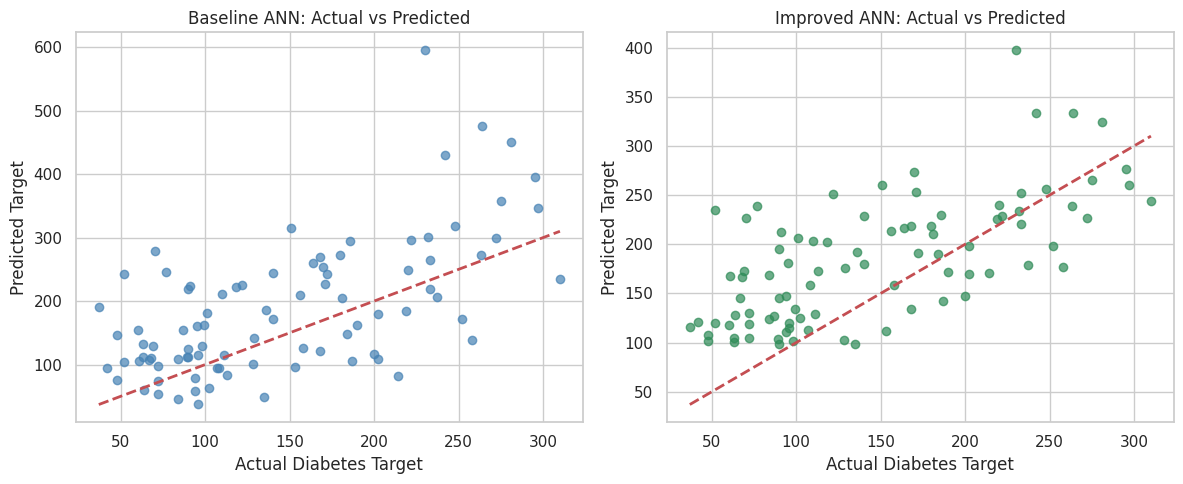

In [45]:
# Actual vs Predicted Scatter Plots
print("\n Actual vs Predicted Values Scatter Plots ")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_base, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Baseline ANN: Actual vs Predicted')
plt.xlabel('Actual Diabetes Target')
plt.ylabel('Predicted Target')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_imp, alpha=0.7, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Improved ANN: Actual vs Predicted')
plt.xlabel('Actual Diabetes Target')
plt.ylabel('Predicted Target')

plt.tight_layout()
plt.show()

# **Conclusion**
This assignment sucessfully built and evaluated an Artificial Neural Network(ANN) regression pipeline on the Diabetes dataset.



*   Baseline Performance : A simple single hidden layer ANN established the foundational baseline, predicting disease progression with standard mean squared error metrics.

*   Optimization & Regularization: Transitioning to a deeper architecture with L2 regularization,Dropout layers, and Early Stopping mitigated overfitting, stabilized training convergence, and improved test set metrics (R2 score and RSME)

*   Key Finding:Hyperparameter tuning and structural regularization are essential for preventing neural networks from memorizing noise on small to medium tabular regression datasets.




